In [1]:
import pandas as pd
df=pd.read_csv(r"C:\Users\Login\Downloads\final dataset.csv")
df.head()

,Date,Open,High,Low,Close,Shares Traded,Turnover (? Cr)
0,05/Mar/26,24615.95,24854.20,24529.40,24765.90,504339053,40011.88
1,04/Mar/26,24388.80,24602.45,24305.40,24480.50,598993881,47700.19
2,02/Mar/26,24659.25,24989.35,24603.50,24865.70,519228821,41306.37
3,27/Feb/26,25459.85,25476.40,25141.30,25178.65,438924282,38634.68
4,26/Feb/26,25556.30,25572.95,25400.95,25496.55,405219244,33155.50


In [2]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2725 entries, 0 to 2724
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Date             2725 non-null   str    
 1   Open             2725 non-null   float64
 2   High             2725 non-null   float64
 3   Low              2725 non-null   float64
 4   Close            2725 non-null   float64
 5   Shares Traded    2725 non-null   int64  
 6   Turnover (? Cr)  2725 non-null   float64
dtypes: float64(5), int64(1), str(1)
memory usage: 149.2 KB


In [3]:
df.describe()

,Open,High,Low,Close,Shares Traded,Turnover (? Cr)
count,2725.000000,2725.000000,2725.000000,2725.000000,2.725000e+03,2725.000000
mean,14790.778550,14857.313615,14701.953596,14781.106991,3.305051e+08,20947.505413
std,5836.472878,5857.933014,5813.769569,5836.642355,1.839840e+08,10906.804556
min,7023.650000,7034.200000,6825.800000,6970.600000,1.661087e+07,805.890000
25%,9996.550000,10040.750000,9947.000000,9984.800000,2.091878e+08,11461.960000
50%,12108.400000,12137.150000,12023.700000,12073.750000,2.744474e+08,20324.670000
75%,18671.250000,18728.900000,18631.800000,18688.100000,3.918220e+08,27629.710000
max,26333.700000,26373.200000,26210.050000,26328.550000,1.811564e+09,93786.440000


In [4]:
df.columns

Index(['Date ', 'Open ', 'High ', 'Low ', 'Close ', 'Shares Traded ',
       'Turnover (? Cr)'],
      dtype='str')

In [5]:
df.columns = df.columns.str.strip()
print(df.columns)
print(df.isnull().sum())

Index(['Date', 'Open', 'High', 'Low', 'Close', 'Shares Traded',
       'Turnover (? Cr)'],
      dtype='str')
Date               0
Open               0
High               0
Low                0
Close              0
Shares Traded      0
Turnover (? Cr)    0
dtype: int64


In [6]:
df['Date'] = pd.to_datetime(df['Date'],format="%d/%b/%y") #here the date was originally in str format so we converted it into datetime format
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2725 entries, 0 to 2724
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   Date             2725 non-null   datetime64[us]
 1   Open             2725 non-null   float64       
 2   High             2725 non-null   float64       
 3   Low              2725 non-null   float64       
 4   Close            2725 non-null   float64       
 5   Shares Traded    2725 non-null   int64         
 6   Turnover (? Cr)  2725 non-null   float64       
dtypes: datetime64[us](1), float64(5), int64(1)
memory usage: 149.2 KB


In [7]:
df['Year'] = df['Date'].dt.year  """We create new columns:Year and Month for time-based analysis Daily Change to measure daily market movement"""
df['Month'] = df['Date'].dt.month
df['Daily Change'] = df['Close'] - df['Open'] #Daily Change represents the difference between closing and opening price indicating profit or loss in a day.
df.head()

,Date,Open,High,Low,Close,Shares Traded,Turnover (? Cr),Year,Month,Daily Change
0,2026-03-05,24615.95,24854.20,24529.40,24765.90,504339053,40011.88,2026,3,149.95
1,2026-03-04,24388.80,24602.45,24305.40,24480.50,598993881,47700.19,2026,3,91.70
2,2026-03-02,24659.25,24989.35,24603.50,24865.70,519228821,41306.37,2026,3,206.45
3,2026-02-27,25459.85,25476.40,25141.30,25178.65,438924282,38634.68,2026,2,-281.20
4,2026-02-26,25556.30,25572.95,25400.95,25496.55,405219244,33155.50,2026,2,-59.75


In [8]:
print("Mean Close:", df['Close'].mean())  #The average closing price is around 14781, showing the general market level. The wide range between minimum and maximum indicates strong market growth.
print("Median Close:", df['Close'].median())
print("Minimum Close:", df['Close'].min())
print("Maximum Close:", df['Close'].max())

Mean Close: 14781.106990825687
Median Close: 12073.75
Minimum Close: 6970.6
Maximum Close: 26328.55


In [9]:
print("Mean Daily Change:", df['Daily Change'].mean()) #The negative mean daily change suggests that slightly more days had losses than gains.
print("Max Gain:", df['Daily Change'].max())
print("Max Loss:", df['Daily Change'].min())

Mean Daily Change: -9.671559633027545
Max Gain: 847.6000000000004
Max Loss: -1295.0


In [10]:
positive_days = (df['Daily Change'] > 0).sum()
negative_days = (df['Daily Change'] < 0).sum()
print("Positive Days:", positive_days)
print("Negative Days:", negative_days)

Positive Days: 1265
Negative Days: 1459


In [11]:
top_gains = df.sort_values(by='Daily Change', ascending=False).head(5)
print(top_gains[['Date', 'Daily Change']])
#The highest gain occurred during market recovery period

           Date  Daily Change
1483 2020-03-13         847.6
1475 2020-03-25         582.7
1602 2019-09-20         527.4
1262 2021-02-01         522.6
205  2025-05-12         504.6


In [12]:
top_losses = df.sort_values(by='Daily Change').head(5)
print(top_losses[['Date', 'Daily Change']])
#the biggest losses correspond to market crashes

           Date  Daily Change
436  2024-06-04      -1295.00
1480 2020-03-18       -619.65
21   2026-02-03       -580.50
23   2026-02-01       -508.30
524  2024-01-23       -477.90


In [13]:
yearly_avg = df.groupby('Year')['Close'].mean()
print(yearly_avg)
#The yearly average closing price shows a clear upward trend, indicating long-term market growth.

Year
2015     8206.617157
2016     8092.193927
2017     9590.717944
2018    10749.392276
2019    11432.632245
2020    11161.474802
2021    16026.760685
2022    17245.430444
2023    18903.131707
2024    23482.061089
2025    24575.608032
2026    25557.006818
Name: Close, dtype: float64


In [14]:
monthly_avg = df.groupby('Month')['Close'].mean()
print(monthly_avg)

Month
1     15478.543404
2     15529.568100
3     13727.082207
4     13905.303382
5     14026.174678
6     14199.493750
7     14717.474792
8     14770.530349
9     15215.116814
10    15191.376682
11    15098.949099
12    15437.989362
Name: Close, dtype: float64


In [15]:
print("Fluctuation(Std Dev of Close):", df['Close'].std())

Fluctuation(Std Dev of Close): 5836.642355054537


In [16]:
print(df[['Open','High','Low','Close']].corr())
#All price variables (Open, High, Low, Close) are highly correlated (~0.99), indicating strong linear relationships in stock prices.

           Open      High       Low     Close
Open   1.000000  0.999922  0.999881  0.999800
High   0.999922  1.000000  0.999855  0.999906
Low    0.999881  0.999855  1.000000  0.999910
Close  0.999800  0.999906  0.999910  1.000000


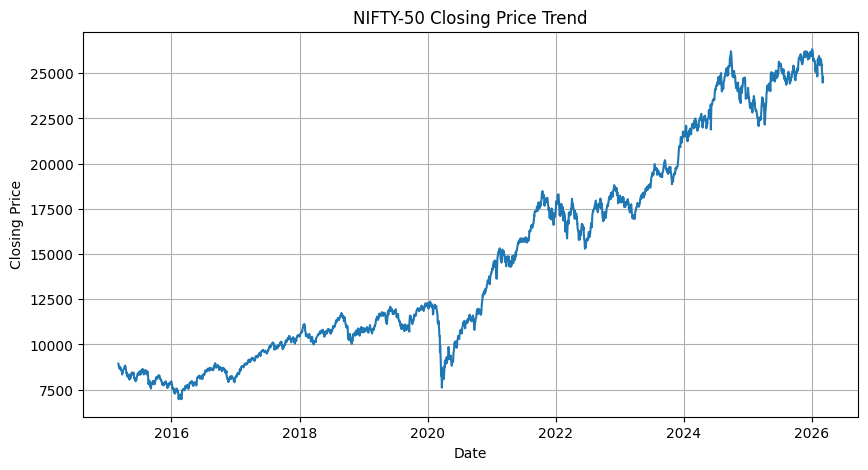

In [17]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10,5))
plt.plot(df['Date'], df['Close'])
plt.xlabel("Date")
plt.ylabel("Closing Price")
plt.title("NIFTY-50 Closing Price Trend")
plt.grid()
plt.show()
#The closing price shows a strong upward trend over time, with noticeable dips during market crises such as 2020.

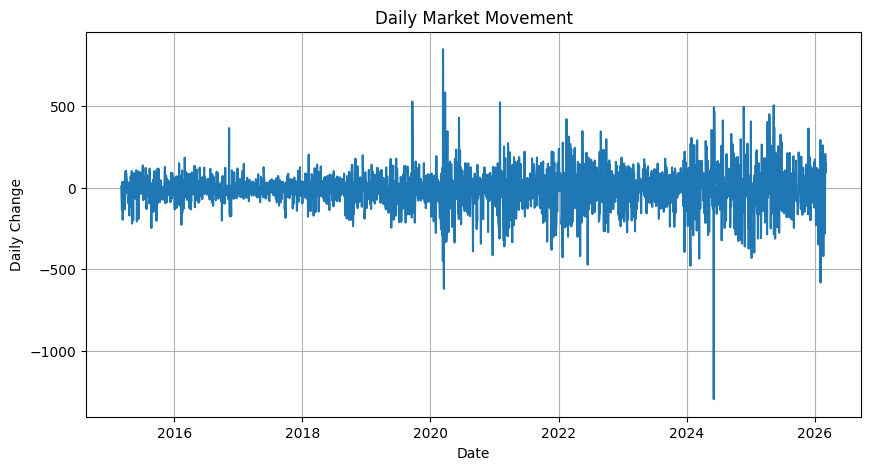

In [18]:
plt.figure(figsize=(10,5))
plt.plot(df['Date'], df['Daily Change'])
plt.xlabel("Date")
plt.ylabel("Daily Change")
plt.title("Daily Market Movement")
plt.grid()
plt.show()
#Daily changes fluctuate around zero, with occasional spikes indicating high volatility periods.

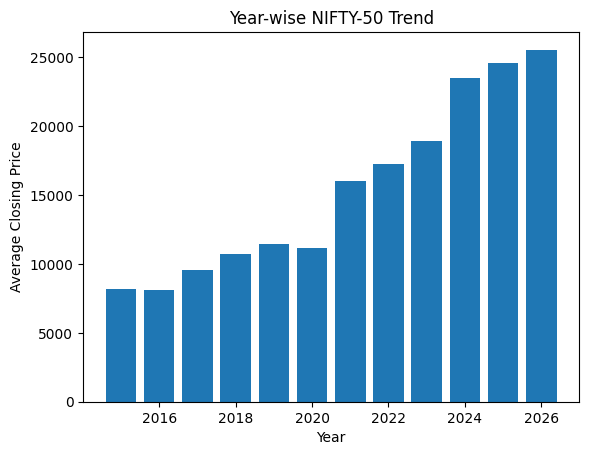

In [19]:
yearly_avg = df.groupby('Year')['Close'].mean()
plt.figure()
plt.bar(yearly_avg.index, yearly_avg.values)
plt.xlabel("Year")
plt.ylabel("Average Closing Price")
plt.title("Year-wise NIFTY-50 Trend")
plt.show()
#The bar chart clearly shows steady growth in market value over the years.

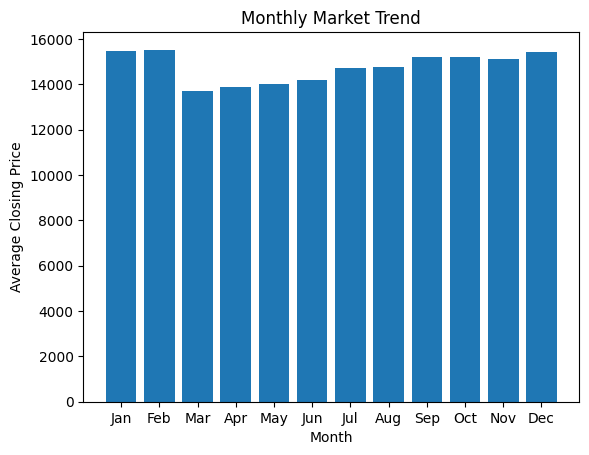

In [20]:
monthly_avg = df.groupby('Month')['Close'].mean()
# Month names
months = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
plt.figure()
plt.bar(months, monthly_avg.values)
plt.xlabel("Month")
plt.ylabel("Average Closing Price")
plt.title("Monthly Market Trend")
plt.show()
#Monthly trends do not show extreme variation, indicating consistent market behavior.

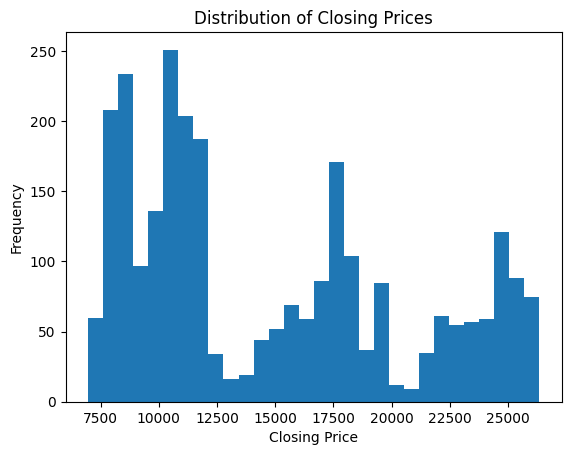

In [21]:
plt.figure()
plt.hist(df['Close'], bins=30)
plt.xlabel("Closing Price")
plt.ylabel("Frequency")
plt.title("Distribution of Closing Prices")
plt.show()
#The distribution of closing prices shows multiple peaks, reflecting different market phases over time.

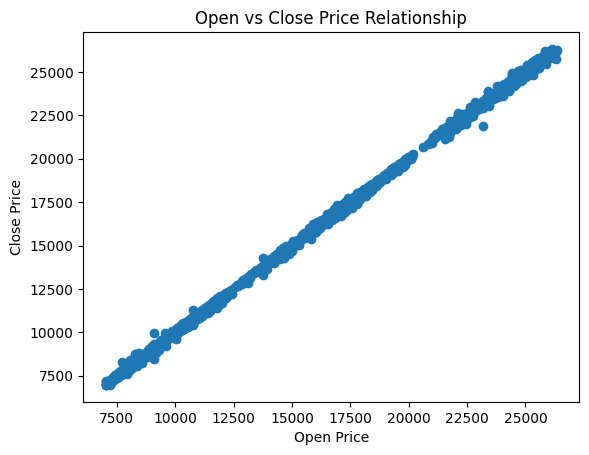

In [22]:
plt.figure()
plt.scatter(df['Open'], df['Close'])
plt.xlabel("Open Price")
plt.ylabel("Close Price")
plt.title("Open vs Close Price Relationship")
plt.show()
#The strong linear pattern confirms high correlation between opening and closing prices.

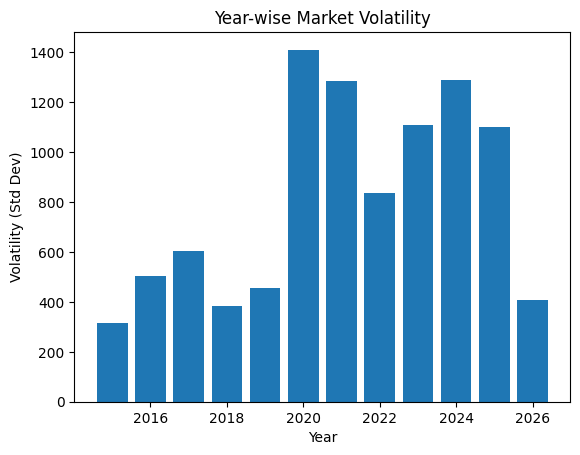

In [23]:
yearly_volatility = df.groupby('Year')['Close'].std()
plt.figure()
plt.bar(yearly_volatility.index, yearly_volatility.values)
plt.xlabel("Year")
plt.ylabel("Volatility (Std Dev)")
plt.title("Year-wise Market Volatility")
plt.show()
#Volatility is highest during crisis periods such as 2020, indicating increased market uncertainty.

In [25]:
"""Final Conclusion

- The NIFTY-50 index shows strong long-term growth.
- Market volatility increases during crisis periods.
- Slightly more negative days than positive days were observed.
- All price variables are highly correlated.
- Overall, the market demonstrates upward momentum with periodic fluctuations."""


'Final Conclusion\n\n- The NIFTY-50 index shows strong long-term growth.\n- Market volatility increases during crisis periods.\n- Slightly more negative days than positive days were observed.\n- All price variables are highly correlated.\n- Overall, the market demonstrates upward momentum with periodic fluctuations.'

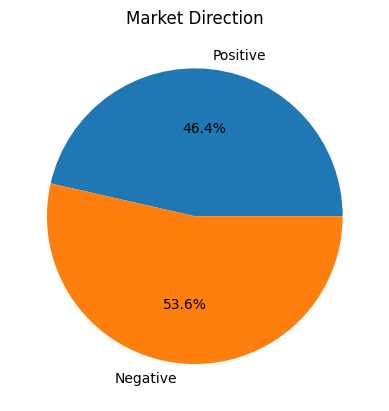

In [26]:
plt.pie([positive_days, negative_days],
        labels=['Positive', 'Negative'],
        autopct='%1.1f%%')
plt.title("Market Direction")
plt.show() # More negative days than positive